## Chatbot with message history using langgraph

Here, we will design a chatbot and start adding features one by one by incorporating all the features present in the langgraph and coming scripts after this etc etc.

Now, in this script, we will build a basic chatbot but this will have user history preservation.

### Lets begin

Lets import all the required modules first


In [2]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages

Lets define the LLM first

In [7]:
model = ChatOpenAI()

Now, lets define the state

Here, to maintain the conversation history , we will store all the messages in a list of langraph message objects, with reducer function, because we need to inform the graph that we need to add the data to this field and not replace , since it is a list.

Now, till now we used to use operator.add as the reducer function , but now we will use the langraph's builtin reducer called add_messages, which works well when we want to maintain a list of langgraph message objects such as AImessage, Humanmessage etc etc, which are all of the type 'BaseMessage' that's we will import that one and give it as the type, when defining the state.

In [8]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

Now, lets first build the nodes required for the graph

In [9]:
def chat_node(State: ChatState):
    #take the query from the state ( all the messages with the current message included )
    messages = State['messages']

    #Send it to LLM
    response = model.invoke(messages)

    #Add the response to the state
    #Here since we have the need to append the messages, send them in the form if a list
    return {'messages': [response]}

Lets build the graph

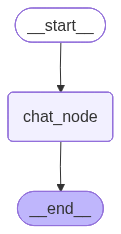

In [10]:
graph = StateGraph(ChatState )

#Here there is only one node
graph.add_node('chat_node', chat_node)

#now lets add the edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

#Now lets compile the graph
workflow = graph.compile()

workflow



Now, lets try this out

In [11]:
initial_state = {
    'messages': [HumanMessage(content="What is the capital of China?")]
}

final_state = workflow.invoke(initial_state)

final_state

{'messages': [HumanMessage(content='What is the capital of China?', additional_kwargs={}, response_metadata={}, id='324a340b-408a-400d-814e-18447944c8c2'),
  AIMessage(content='Beijing', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 14, 'total_tokens': 16, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgT3VCwzWb5tHBAq6nDIEubfym8xj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e357c-d71d-75f0-b47c-90137f2eb493-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 2, 'total_tokens': 16, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, '

Lets try with one more message to see if the history is preserved

In [13]:
initial_state = {
    'messages': [HumanMessage(content="What is the question that Ii asked before?")]
}

final_state = workflow.invoke(initial_state)

final_state

{'messages': [HumanMessage(content='What is the question that Ii asked before?', additional_kwargs={}, response_metadata={}, id='0d8ef2ff-2365-4d59-a874-d733a8e8323c'),
  AIMessage(content="I'm sorry, but I do not have the ability to remember previous interactions. Please feel free to ask your question again.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 17, 'total_tokens': 42, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgT8DSj1zYP7lzMTrAp8q79Wqu2UN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3581-5551-7c10-be13-572bfe9683b7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'outp

Here we, notice there is huge problem, the message history is not being saved, because we are not storing the state, we are initiating the state each time newly without history so that's why.

### We will solve this history problem , with the help of a concept called persistance in langgraph.

Solution is simple, whenever a workflow ends, we need to simply store  the state somewhere, like a database or a file or something etc, and then when we invoke it again, we pass this saved state again, so that it will have the full history all the time. Or we can simply store it in the RAM also, if we are not that serious about the history, it will stay until atleast this script runs etc.

Now, to do this in langgraph , we use module called MemorySaver and make some changes while defining the workflow.

We just pass this object while compiling the graph, that's it.

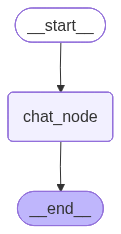

In [14]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph = StateGraph(ChatState )

#Here there is only one node
graph.add_node('chat_node', chat_node)

#now lets add the edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

#Now lets compile the graph
workflow = graph.compile(checkpointer=checkpointer)

workflow

Now, lets try this again.

Now, before invoking, like assume every user has a unique id and like we will start a thread with that id, and store all the msaages related to that user in that thread etc. Now, it acts like a key of the dictionary etc.

Now, apart from this, we will also pass a dictionary called config, which consists of keys called 'configurable' and inside that we will have this 'thread_id' key and in that we will pass our unique number etc and the value to that key.

In [15]:
thread_id = 1

initial_state = {
    'messages': [HumanMessage(content="What is the capital of china?")]
}

config = {'configurable': {'thread_id': [thread_id]}}

#Now send this config also along with the message, while invoking
final_state = workflow.invoke(initial_state, config=config)

final_state

{'messages': [HumanMessage(content='What is the capital of china?', additional_kwargs={}, response_metadata={}, id='4a79a632-5c3a-450e-8263-856c038c34f8'),
  AIMessage(content='The capital of China is Beijing.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgTNp7PtBmCt4RTn3HuCgMVDAa9zo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3590-17b6-7223-ab25-956cd949bae5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token

Now, lets check again with one more message.

In [16]:
thread_id = 1

initial_state = {
    'messages': [HumanMessage(content="What is the question that i asked before?")]
}

config = {'configurable': {'thread_id': [thread_id]}}

#Now send this config also along with the message, while invoking
final_state = workflow.invoke(initial_state, config=config)

final_state

{'messages': [HumanMessage(content='What is the capital of china?', additional_kwargs={}, response_metadata={}, id='4a79a632-5c3a-450e-8263-856c038c34f8'),
  AIMessage(content='The capital of China is Beijing.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgTNp7PtBmCt4RTn3HuCgMVDAa9zo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3590-17b6-7223-ab25-956cd949bae5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token

#### Now, the history is preserved 

Let's try to get the actual chatbot experience by running this in a loop etc .

In [17]:
thread_id = 2

while True:

    user_message = input('Type here: ')

    print('User :', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break 

    config = {'configurable': {'thread_id': thread_id}}

    response = workflow.invoke({'messages': [HumanMessage(content=user_message)]}, config= config)

    print('AI: ', response['messages'][-1].content)

User : Hi my name is dragon, who are you?
AI:  Hello Dragon, I am an AI assistant here to help you. How can I assist you today?
User : what is my name?
AI:  Your name is Dragon. How can I assist you today?
User : add 100 and 50
AI:  100 + 50 is equal to 150.
User : Now divide that by 3
AI:  150 divided by 3 is equal to 50.
User : now what is the first number that i told?
AI:  The first number you mentioned was 100.
User : end
AI:  If you have any more questions in the future, feel free to ask. Have a great day! Goodbye!
User : exit


Now, we can get the whole state of any thread by passing the config to the workflow.get_state() function

In [22]:
config = {'configurable': {'thread_id': 2}}

workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi my name is dragon, who are you?', additional_kwargs={}, response_metadata={}, id='641f16ab-2947-4ac1-9d8b-3154f94f09a5'), AIMessage(content='Hello Dragon, I am an AI assistant here to help you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 17, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgTUspyXsqn4BQ2mwNmwFEkZHPj1C', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3596-c57d-7942-8b49-fc555ffbe8fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 20, 'total_tokens

lets store this and analyze this in detail

In [23]:
snapshot = workflow.get_state(config=config)
snapshot.values

{'messages': [HumanMessage(content='Hi my name is dragon, who are you?', additional_kwargs={}, response_metadata={}, id='641f16ab-2947-4ac1-9d8b-3154f94f09a5'),
  AIMessage(content='Hello Dragon, I am an AI assistant here to help you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 17, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DgTUspyXsqn4BQ2mwNmwFEkZHPj1C', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3596-c57d-7942-8b49-fc555ffbe8fd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 20, 'total_tokens': 37, 'input_token